# Academic Dataset Test - Stage 3 Extraction

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 1.0.0 | 2026-01-25 | That Le | Test Stage 3 on real academic charts |

## Objectives

1. Load and explore the academic dataset (2,852 charts, 13,297 QA pairs)
2. Test Stage 3 extraction pipeline on real charts
3. Evaluate chart type classification accuracy
4. Compare extracted data with AI-generated QA pairs
5. Identify failure cases for improvement

## 1. Setup and Imports

In [1]:
import sys
import json
from pathlib import Path
from collections import Counter
import random

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: d:\elix\chart_analysis_ai_v3


In [7]:
# Import Stage 3 components
from src.core_engine.stages.s3_extraction.preprocessor import ImagePreprocessor
from src.core_engine.stages.s3_extraction.simple_classifier import SimpleChartClassifier
from src.core_engine.stages.s3_extraction.element_detector import ElementDetector

# Initialize components
preprocessor = ImagePreprocessor()
classifier = SimpleChartClassifier()
element_detector = ElementDetector()

print("Stage 3 components loaded successfully!")

Stage 3 components loaded successfully!


## 2. Load Academic Dataset

In [8]:
# Load dataset.json
dataset_path = project_root / "data" / "academic_dataset" / "chart_qa" / "dataset.json"

with open(dataset_path, 'r', encoding='utf-8') as f:
    dataset = json.load(f)

print(f"Dataset version: {dataset['version']}")
print(f"Created at: {dataset['created_at']}")
print(f"Total images: {dataset['total_images']}")
print(f"Total QA pairs: {dataset['total_qa_pairs']}")
print(f"Average QA pairs per chart: {dataset['total_qa_pairs'] / dataset['total_images']:.2f}")

Dataset version: 1.0.0
Created at: 2026-01-24T03:45:00.399849
Total images: 2852
Total QA pairs: 13297
Average QA pairs per chart: 4.66


In [9]:
# Extract samples
samples = dataset['samples']

# Chart type distribution
chart_types = Counter([s['chart_type'] for s in samples])
print("\nChart Type Distribution:")
print("-" * 40)
for chart_type, count in chart_types.most_common():
    pct = count / len(samples) * 100
    print(f"{chart_type:12} : {count:4} ({pct:5.1f}%)")


Chart Type Distribution:
----------------------------------------
line         :  904 ( 31.7%)
bar          :  598 ( 21.0%)
scatter      :  409 ( 14.3%)
other        :  271 (  9.5%)
heatmap      :  209 (  7.3%)
area         :  187 (  6.6%)
histogram    :  102 (  3.6%)
pie          :   96 (  3.4%)
box          :   76 (  2.7%)


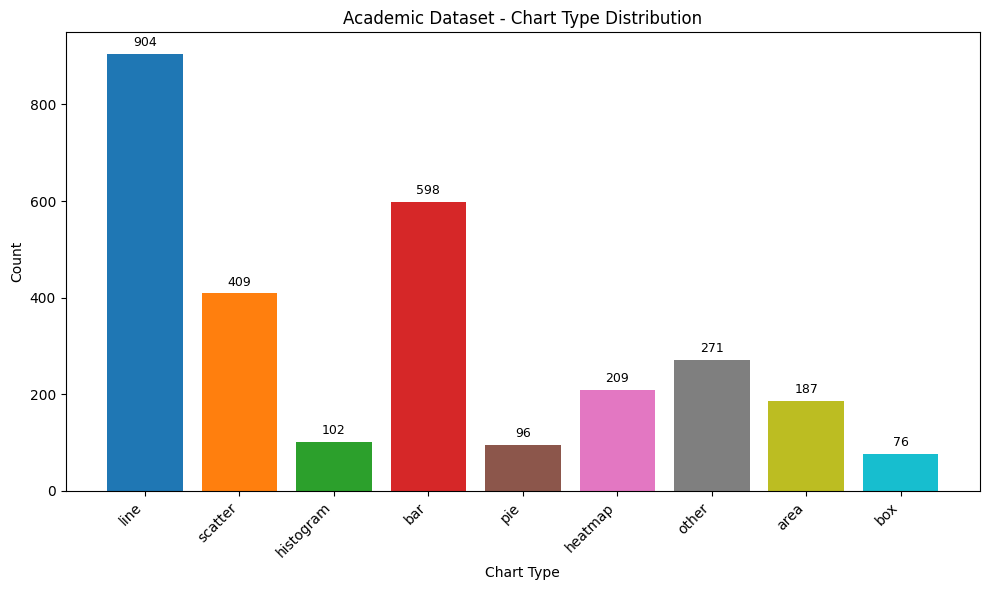

In [10]:
# Visualize chart type distribution
fig, ax = plt.subplots(figsize=(10, 6))
types = list(chart_types.keys())
counts = list(chart_types.values())

colors = plt.cm.tab10(np.linspace(0, 1, len(types)))
bars = ax.bar(types, counts, color=colors)

ax.set_xlabel('Chart Type')
ax.set_ylabel('Count')
ax.set_title('Academic Dataset - Chart Type Distribution')

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            str(count), ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# QA type distribution
qa_types = Counter()
for sample in samples:
    for qa in sample['qa_pairs']:
        qa_types[qa['question_type']] += 1

print("\nQA Type Distribution:")
print("-" * 40)
for qa_type, count in qa_types.most_common():
    pct = count / sum(qa_types.values()) * 100
    print(f"{qa_type:15} : {count:5} ({pct:5.1f}%)")


QA Type Distribution:
----------------------------------------
structural      :  2852 ( 21.4%)
counting        :  2833 ( 21.3%)
comparison      :  2558 ( 19.2%)
reasoning       :  2534 ( 19.1%)
extraction      :  2520 ( 19.0%)


## 3. Sample Charts by Type

In [12]:
def get_samples_by_type(samples, chart_type, n=5):
    """Get n random samples of a specific chart type."""
    filtered = [s for s in samples if s['chart_type'] == chart_type]
    return random.sample(filtered, min(n, len(filtered)))

def display_sample(sample, show_qa=True):
    """Display a sample chart with its QA pairs."""
    img_path = Path(sample['image_path'])
    
    if not img_path.exists():
        print(f"Image not found: {img_path}")
        return None
    
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img_rgb)
    ax.set_title(f"ID: {sample['image_id']} | Type: {sample['chart_type']}")
    ax.axis('off')
    plt.show()
    
    if show_qa:
        print("\nQA Pairs:")
        print("-" * 60)
        for i, qa in enumerate(sample['qa_pairs'], 1):
            print(f"Q{i} [{qa['question_type']}]: {qa['question']}")
            print(f"A{i}: {qa['answer']}")
            print()
    
    return img

In [ ]:
# Display sample charts of each type
random.seed(42)  # For reproducibility

for chart_type in ['bar', 'line', 'pie', 'scatter']:
    print(f"\n{'='*60}")
    print(f"CHART TYPE: {chart_type.upper()}")
    print(f"{'='*60}")
    
    type_samples = get_samples_by_type(samples, chart_type, n=1)
    if type_samples:
        display_sample(type_samples[0], show_qa=True)

## 4. Test Chart Classification

In [14]:
def test_classification(samples, n_per_type=10):
    """Test chart classification on samples."""
    # Supported types mapping (dataset type -> our classifier type)
    type_mapping = {
        'bar': 'bar',
        'line': 'line',
        'pie': 'pie',
        'scatter': 'scatter',
        'area': 'line',  # Area charts often detected as line
        'histogram': 'bar',  # Histograms are bar-like
    }
    
    results = {
        'total': 0,
        'correct': 0,
        'by_type': {}
    }
    
    for chart_type in ['bar', 'line', 'pie', 'scatter']:
        type_samples = get_samples_by_type(samples, chart_type, n=n_per_type)
        
        correct = 0
        total = len(type_samples)
        errors = []
        
        for sample in type_samples:
            img_path = Path(sample['image_path'])
            if not img_path.exists():
                continue
                
            img = cv2.imread(str(img_path))
            result = classifier.classify(img)
            predicted_type = result.chart_type.value
            confidence = result.confidence
            
            expected = type_mapping.get(chart_type, chart_type)
            
            if predicted_type == expected:
                correct += 1
            else:
                errors.append({
                    'image_id': sample['image_id'],
                    'expected': expected,
                    'predicted': predicted_type,
                    'confidence': confidence
                })
        
        accuracy = correct / total if total > 0 else 0
        results['by_type'][chart_type] = {
            'total': total,
            'correct': correct,
            'accuracy': accuracy,
            'errors': errors
        }
        results['total'] += total
        results['correct'] += correct
        
    results['overall_accuracy'] = results['correct'] / results['total'] if results['total'] > 0 else 0
    return results

# Run classification test
print("Testing chart classification...")
print("(This may take a few minutes)")
print()

classification_results = test_classification(samples, n_per_type=20)

Testing chart classification...
(This may take a few minutes)



In [15]:
# Display classification results
print("\nClassification Results:")
print("=" * 50)
print(f"Overall Accuracy: {classification_results['overall_accuracy']*100:.1f}%")
print(f"Total Tested: {classification_results['total']}")
print(f"Correct: {classification_results['correct']}")
print()

print("By Chart Type:")
print("-" * 50)
for chart_type, data in classification_results['by_type'].items():
    status = "PASS" if data['accuracy'] >= 0.8 else "FAIL"
    print(f"{chart_type:10} : {data['correct']:2}/{data['total']:2} ({data['accuracy']*100:5.1f}%) [{status}]")


Classification Results:
Overall Accuracy: 37.5%
Total Tested: 80
Correct: 30

By Chart Type:
--------------------------------------------------
bar        :  8/20 ( 40.0%) [FAIL]
line       :  0/20 (  0.0%) [FAIL]
pie        :  5/20 ( 25.0%) [FAIL]
scatter    : 17/20 ( 85.0%) [PASS]


In [16]:
# Show error cases
print("\nError Cases (Misclassified Charts):")
print("=" * 60)

for chart_type, data in classification_results['by_type'].items():
    if data['errors']:
        print(f"\n{chart_type.upper()} errors:")
        for err in data['errors'][:3]:  # Show first 3 errors
            print(f"  - {err['image_id']}: expected={err['expected']}, got={err['predicted']} (conf={err['confidence']:.2f})")


Error Cases (Misclassified Charts):

BAR errors:
  - arxiv_2601_10804v1_p15_img00: expected=bar, got=scatter (conf=0.52)
  - arxiv_2601_09421v2_p20_img00: expected=bar, got=scatter (conf=0.79)
  - arxiv_1801_08163v2_p04_img02: expected=bar, got=scatter (conf=0.67)

LINE errors:
  - arxiv_2601_09018v1_p07_img00: expected=line, got=scatter (conf=0.41)
  - arxiv_2601_09814v1_p13_img01: expected=line, got=scatter (conf=0.62)
  - arxiv_2601_10159v1_p05_img03: expected=line, got=scatter (conf=0.45)

PIE errors:
  - arxiv_2601_11389v1_p20_img01: expected=pie, got=scatter (conf=0.70)
  - arxiv_2601_01446v1_p12_img00: expected=pie, got=line (conf=0.75)
  - arxiv_2601_10951v1_p09_img02: expected=pie, got=scatter (conf=0.48)

SCATTER errors:
  - arxiv_2601_09248v1_p08_img00: expected=scatter, got=pie (conf=0.52)
  - arxiv_2010_14476v1_p36_img00: expected=scatter, got=bar (conf=0.68)
  - arxiv_2010_14476v1_p35_img00: expected=scatter, got=bar (conf=0.68)


## 5. Test Element Detection

In [24]:
def test_element_detection(sample, show_visualization=True):
    """Test element detection on a single sample."""
    img_path = Path(sample['image_path'])
    if not img_path.exists():
        print(f"Image not found: {img_path}")
        return None
    
    # Load image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess to get binary image
    preprocessed = preprocessor.process(img)
    binary_img = preprocessed.binary_image
    
    # Classify chart type
    result = classifier.classify(img)
    chart_type = result.chart_type.value
    confidence = result.confidence
    
    # Detect elements
    detection_result = element_detector.detect(
        binary_image=binary_img,
        color_image=img,  # BGR format
        chart_id=sample['image_id'],
        chart_type=chart_type
    )
    
    result_dict = {
        'image_id': sample['image_id'],
        'ground_truth_type': sample['chart_type'],
        'predicted_type': chart_type,
        'type_confidence': confidence,
        'bars_detected': len(detection_result.bars),
        'markers_detected': len(detection_result.markers),
        'total_elements': len(detection_result.bars) + len(detection_result.markers)
    }
    
    if show_visualization:
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Original image
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"Original\nGT: {sample['chart_type']} | Pred: {chart_type}")
        axes[0].axis('off')
        
        # Binary image
        axes[1].imshow(binary_img, cmap='gray')
        axes[1].set_title("Binary Image")
        axes[1].axis('off')
        
        # With detected elements
        vis_img = img.copy()
        
        # Draw bars in green
        for bar in detection_result.bars:
            cv2.rectangle(vis_img, 
                         (int(bar.x_min), int(bar.y_min)),
                         (int(bar.x_max), int(bar.y_max)),
                         (0, 255, 0), 2)
        
        # Draw markers in blue
        for marker in detection_result.markers:
            cv2.circle(vis_img, (int(marker.center.x), int(marker.center.y)), 5, (255, 0, 0), -1)
        
        vis_img_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
        axes[2].imshow(vis_img_rgb)
        axes[2].set_title(f"Detected: {result_dict['bars_detected']} bars, {result_dict['markers_detected']} markers")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print element details
        if detection_result.bars:
            print(f"\nDetected {result_dict['bars_detected']} bars:")
            for i, bar in enumerate(detection_result.bars[:10], 1):  # Show first 10
                color = bar.color
                color_str = f"RGB({color.r}, {color.g}, {color.b})" if color else "N/A"
                print(f"  {i}. Color: {color_str}, BBox: ({bar.x_min:.0f},{bar.y_min:.0f})-({bar.x_max:.0f},{bar.y_max:.0f})")
        
        if detection_result.markers:
            print(f"\nDetected {result_dict['markers_detected']} markers:")
            for i, marker in enumerate(detection_result.markers[:10], 1):
                color = marker.color
                color_str = f"RGB({color.r}, {color.g}, {color.b})" if color else "N/A"
                print(f"  {i}. Color: {color_str}, Center: ({marker.center.x:.0f},{marker.center.y:.0f})")
    
    return result_dict

Testing Element Detection on BAR Charts:

--- arxiv_2601_08733v1_p05_img02 ---


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


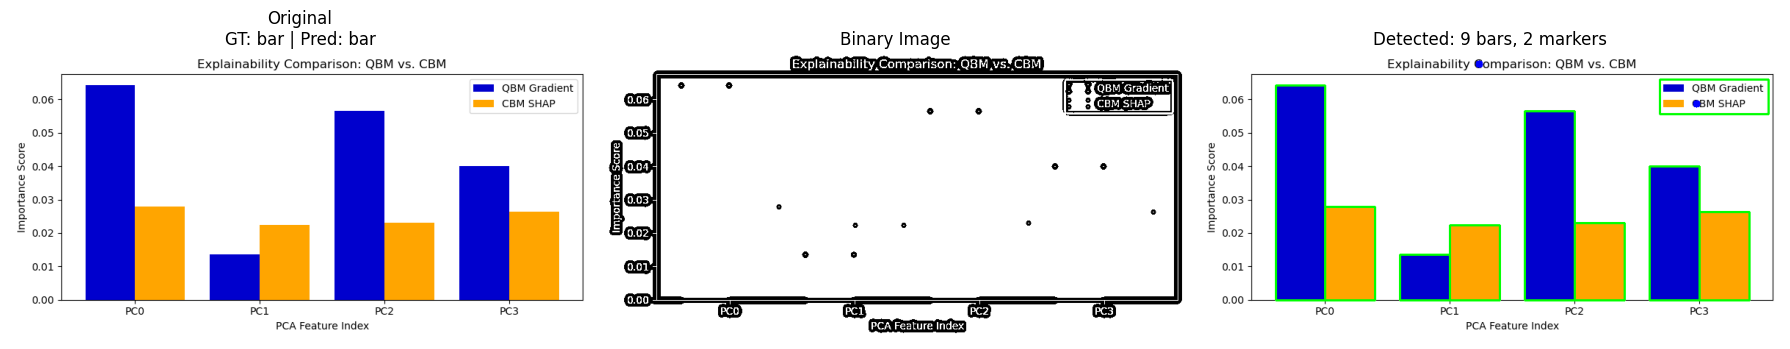


Detected 9 bars:
  1. Color: RGB(0, 0, 204), BBox: (272,275)-(340,337)
  2. Color: RGB(0, 0, 204), BBox: (612,155)-(680,337)
  3. Color: RGB(0, 0, 204), BBox: (442,80)-(510,337)
  4. Color: RGB(0, 0, 204), BBox: (103,45)-(170,337)
  5. Color: RGB(254, 164, 0), BBox: (340,235)-(408,337)
  6. Color: RGB(254, 164, 0), BBox: (510,232)-(578,337)
  7. Color: RGB(254, 164, 0), BBox: (680,217)-(748,337)
  8. Color: RGB(254, 164, 0), BBox: (170,210)-(238,337)
  9. Color: RGB(236, 236, 236), BBox: (626,37)-(774,84)

Detected 2 markers:
  1. Color: RGB(213, 213, 213), Center: (676,70)
  2. Color: RGB(183, 183, 183), Center: (380,16)

--- arxiv_2601_09697v1_p01_img00 ---


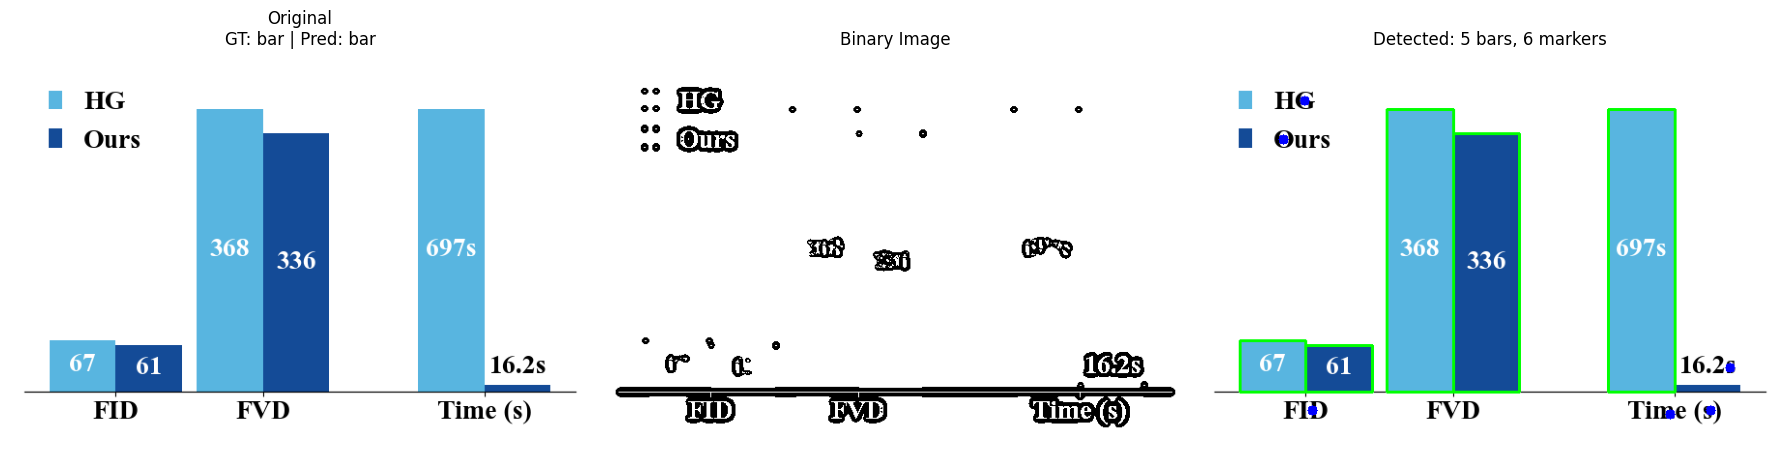


Detected 5 bars:
  1. Color: RGB(88, 180, 223), BBox: (41,298)-(109,351)
  2. Color: RGB(88, 180, 223), BBox: (422,59)-(491,351)
  3. Color: RGB(88, 180, 223), BBox: (193,59)-(262,351)
  4. Color: RGB(20, 75, 150), BBox: (109,303)-(178,351)
  5. Color: RGB(20, 75, 150), BBox: (262,84)-(330,351)

Detected 6 markers:
  1. Color: RGB(181, 181, 181), Center: (86,90)
  2. Color: RGB(196, 196, 196), Center: (528,370)
  3. Color: RGB(152, 152, 152), Center: (108,50)
  4. Color: RGB(190, 190, 190), Center: (548,326)
  5. Color: RGB(160, 160, 160), Center: (116,370)
  6. Color: RGB(149, 149, 149), Center: (486,374)

--- arxiv_2601_08976v1_p12_img04 ---


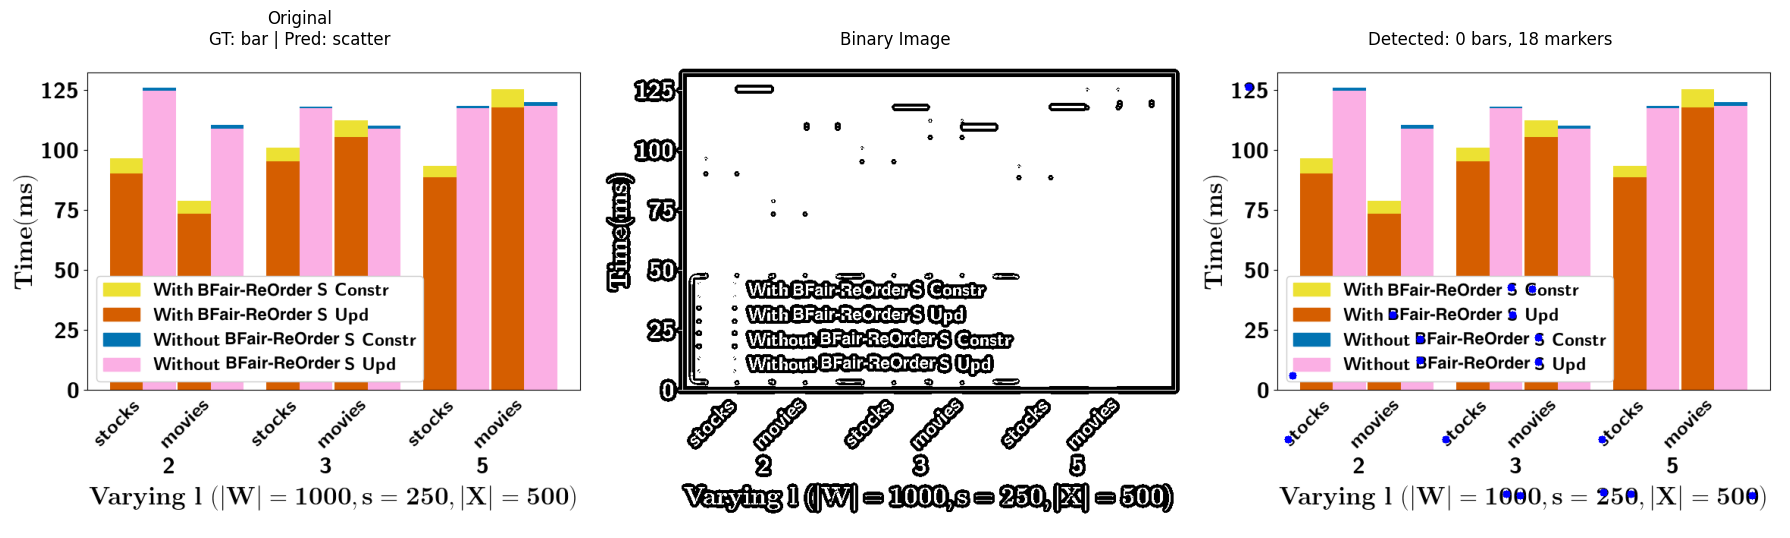


Detected 18 markers:
  1. Color: RGB(171, 171, 171), Center: (422,584)
  2. Color: RGB(187, 187, 187), Center: (728,584)
  3. Color: RGB(186, 186, 186), Center: (446,408)
  4. Color: RGB(205, 205, 205), Center: (412,346)
  5. Color: RGB(202, 202, 202), Center: (532,580)
  6. Color: RGB(186, 186, 186), Center: (410,310)
  7. Color: RGB(186, 186, 186), Center: (446,376)
  8. Color: RGB(177, 177, 177), Center: (116,510)
  9. Color: RGB(164, 164, 164), Center: (324,510)
  10. Color: RGB(177, 177, 177), Center: (530,510)


In [25]:
# Test element detection on bar charts
print("Testing Element Detection on BAR Charts:")
print("=" * 60)

bar_samples = get_samples_by_type(samples, 'bar', n=3)
for sample in bar_samples:
    print(f"\n--- {sample['image_id']} ---")
    test_element_detection(sample)

Testing Element Detection on PIE Charts:

--- arxiv_2601_09688v1_p05_img00 ---


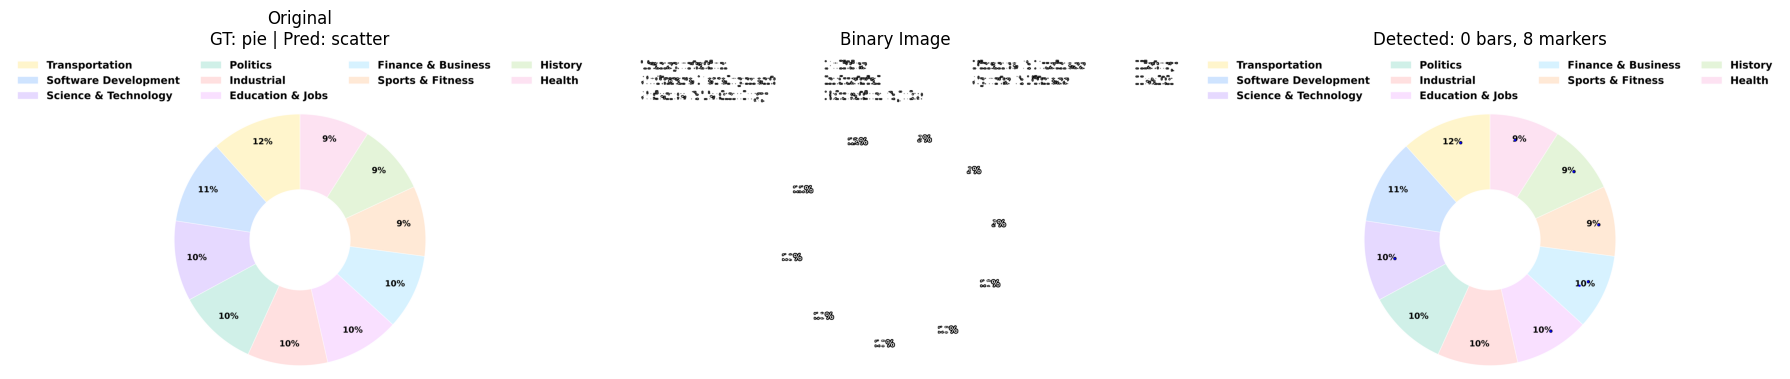


Detected 8 markers:
  1. Color: RGB(168, 162, 135), Center: (1156,398)
  2. Color: RGB(146, 156, 139), Center: (1658,526)
  3. Color: RGB(162, 149, 137), Center: (1768,762)
  4. Color: RGB(153, 144, 168), Center: (864,912)
  5. Color: RGB(141, 158, 165), Center: (1722,1014)
  6. Color: RGB(165, 149, 168), Center: (1556,1234)
  7. Color: RGB(104, 94, 100), Center: (1398,386)
  8. Color: RGB(140, 157, 165), Center: (1684,1032)

--- arxiv_2601_09953v1_p12_img00 ---


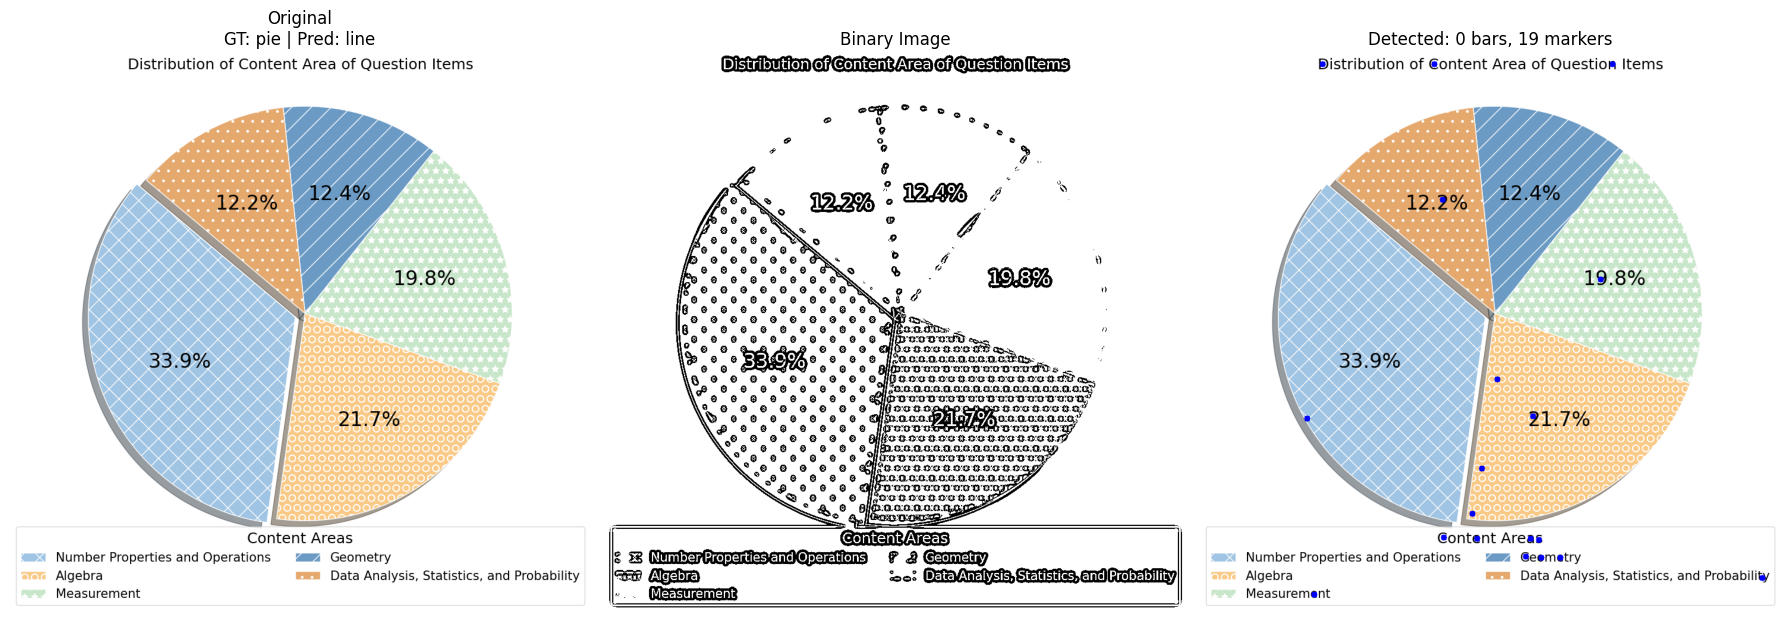


Detected 19 markers:
  1. Color: RGB(187, 187, 187), Center: (466,818)
  2. Color: RGB(180, 180, 180), Center: (410,816)
  3. Color: RGB(189, 189, 189), Center: (556,818)
  4. Color: RGB(195, 195, 195), Center: (694,20)
  5. Color: RGB(171, 171, 171), Center: (548,848)
  6. Color: RGB(151, 151, 151), Center: (192,912)
  7. Color: RGB(209, 209, 209), Center: (206,20)
  8. Color: RGB(250, 218, 172), Center: (500,550)
  9. Color: RGB(186, 139, 93), Center: (408,248)
  10. Color: RGB(249, 217, 170), Center: (458,776)

--- arxiv_2601_01446v1_p12_img00 ---


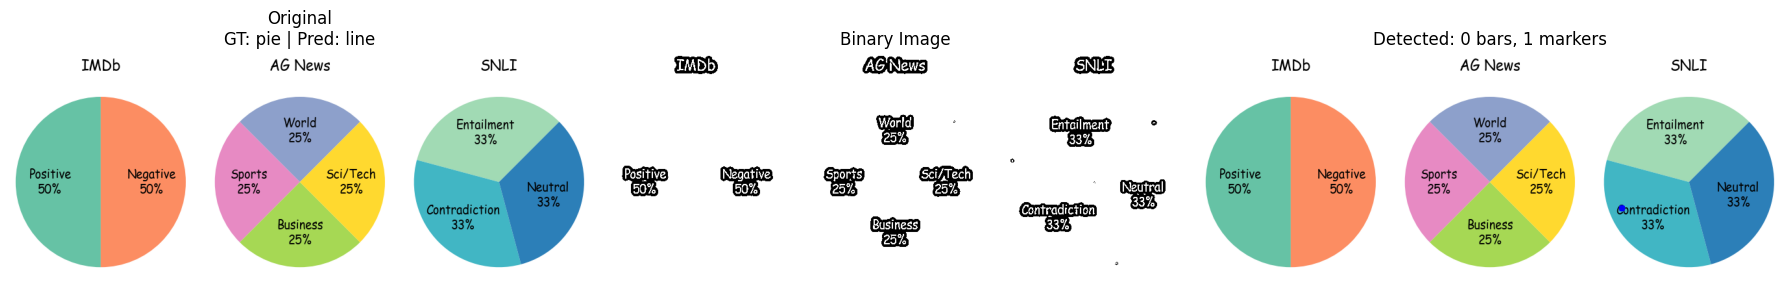


Detected 1 markers:
  1. Color: RGB(47, 133, 144), Center: (650,240)


In [26]:
# Test element detection on pie charts
print("Testing Element Detection on PIE Charts:")
print("=" * 60)

pie_samples = get_samples_by_type(samples, 'pie', n=3)
for sample in pie_samples:
    print(f"\n--- {sample['image_id']} ---")
    test_element_detection(sample)

Testing Element Detection on LINE Charts:

--- arxiv_2601_10513v1_p07_img00 ---


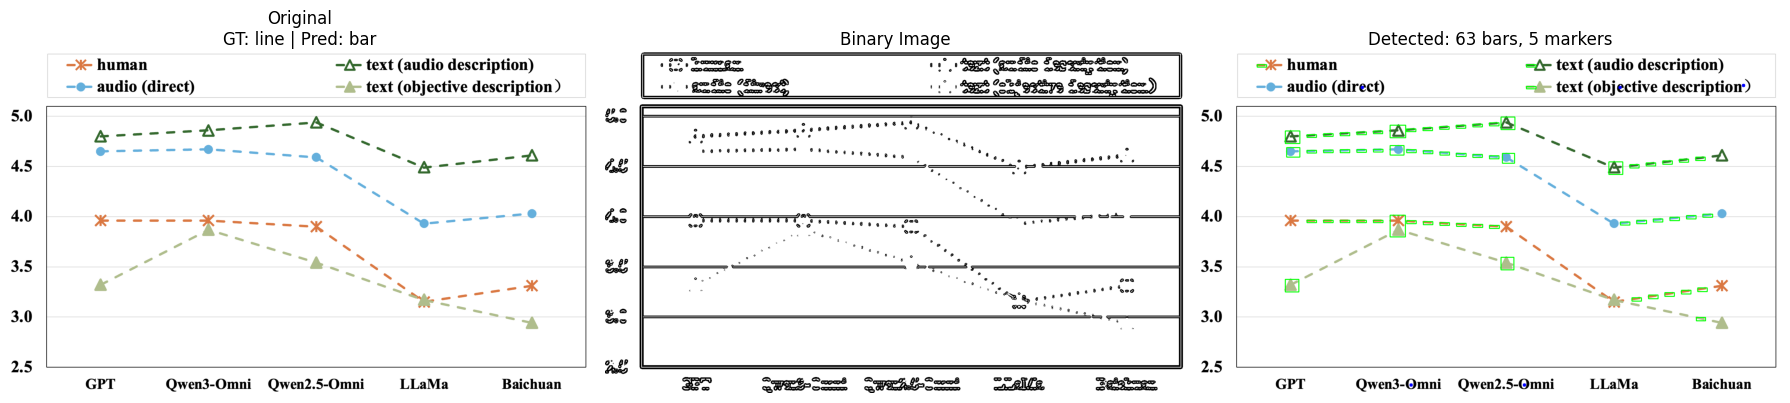


Detected 63 bars:
  1. Color: RGB(195, 205, 169), BBox: (1463,781)-(1490,791)
  2. Color: RGB(232, 172, 138), BBox: (1273,723)-(1301,733)
  3. Color: RGB(232, 172, 139), BBox: (1322,715)-(1350,726)
  4. Color: RGB(232, 171, 137), BBox: (1370,708)-(1398,719)
  5. Color: RGB(232, 172, 139), BBox: (1419,701)-(1447,712)
  6. Color: RGB(232, 172, 139), BBox: (1467,694)-(1495,705)
  7. Color: RGB(187, 199, 157), BBox: (251,669)-(291,706)
  8. Color: RGB(185, 198, 155), BBox: (887,604)-(925,641)
  9. Color: RGB(230, 166, 131), BBox: (853,510)-(882,519)
  10. Color: RGB(230, 166, 131), BBox: (804,507)-(833,516)

Detected 5 markers:
  1. Color: RGB(192, 192, 192), Center: (1602,98)
  2. Color: RGB(141, 141, 141), Center: (622,980)
  3. Color: RGB(153, 153, 153), Center: (478,104)
  4. Color: RGB(143, 143, 143), Center: (956,980)
  5. Color: RGB(157, 157, 157), Center: (1238,104)

--- arxiv_2305_01837v1_p05_img00 ---


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


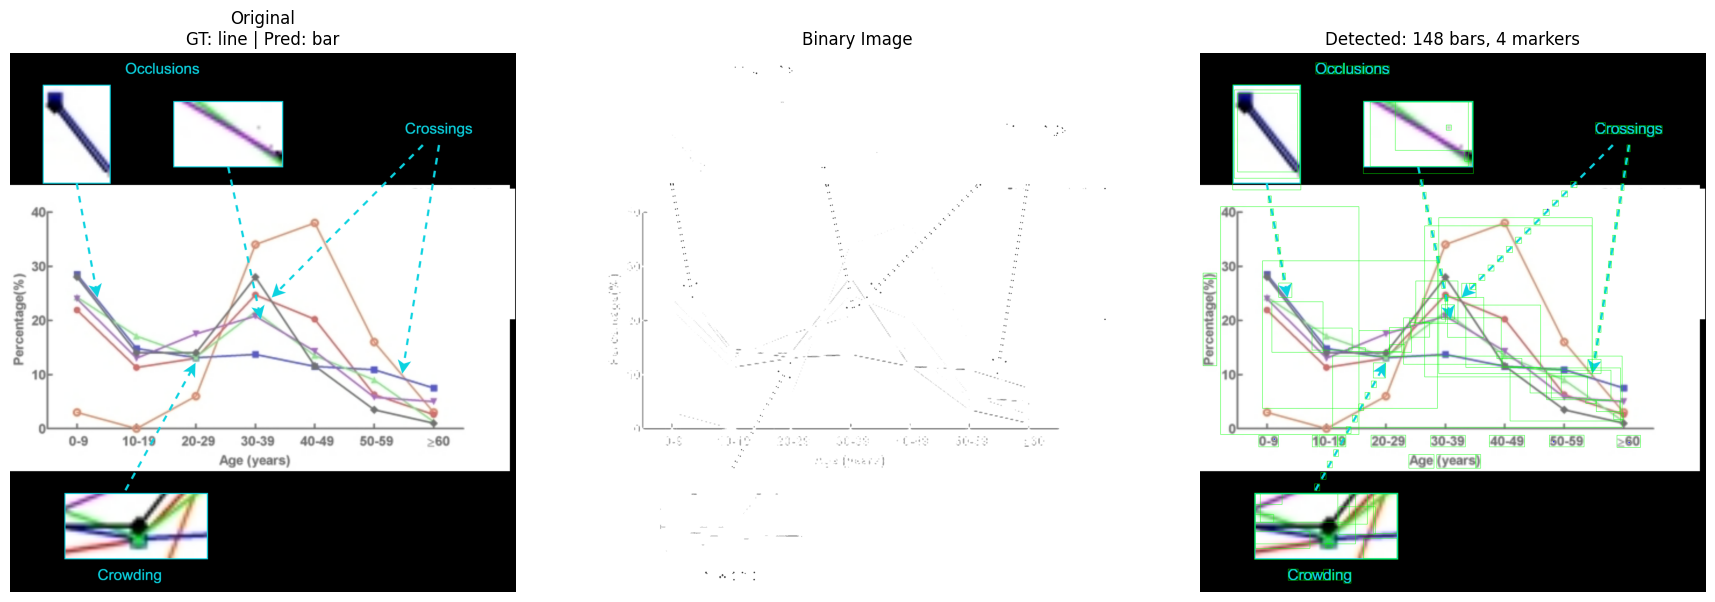


Detected 148 bars:
  1. Color: RGB(55, 73, 98), BBox: (924,3610)-(971,3644)
  2. Color: RGB(55, 73, 98), BBox: (408,3248)-(1143,3614)
  3. Color: RGB(55, 73, 98), BBox: (1945,730)-(2000,803)
  4. Color: RGB(55, 73, 98), BBox: (276,302)-(717,881)
  5. Color: RGB(12, 210, 224), BBox: (974,3822)-(985,3880)
  6. Color: RGB(12, 210, 224), BBox: (824,3822)-(905,3880)
  7. Color: RGB(12, 210, 224), BBox: (1057,3821)-(1110,3903)
  8. Color: RGB(12, 210, 224), BBox: (999,3821)-(1047,3880)
  9. Color: RGB(12, 210, 224), BBox: (765,3821)-(821,3881)
  10. Color: RGB(12, 210, 224), BBox: (731,3821)-(764,3880)

Detected 4 markers:
  1. Color: RGB(157, 157, 157), Center: (3154,2870)
  2. Color: RGB(171, 171, 171), Center: (2600,2864)
  3. Color: RGB(179, 179, 179), Center: (546,2844)
  4. Color: RGB(169, 239, 244), Center: (2556,1156)

--- arxiv_2601_09236v2_p20_img00 ---


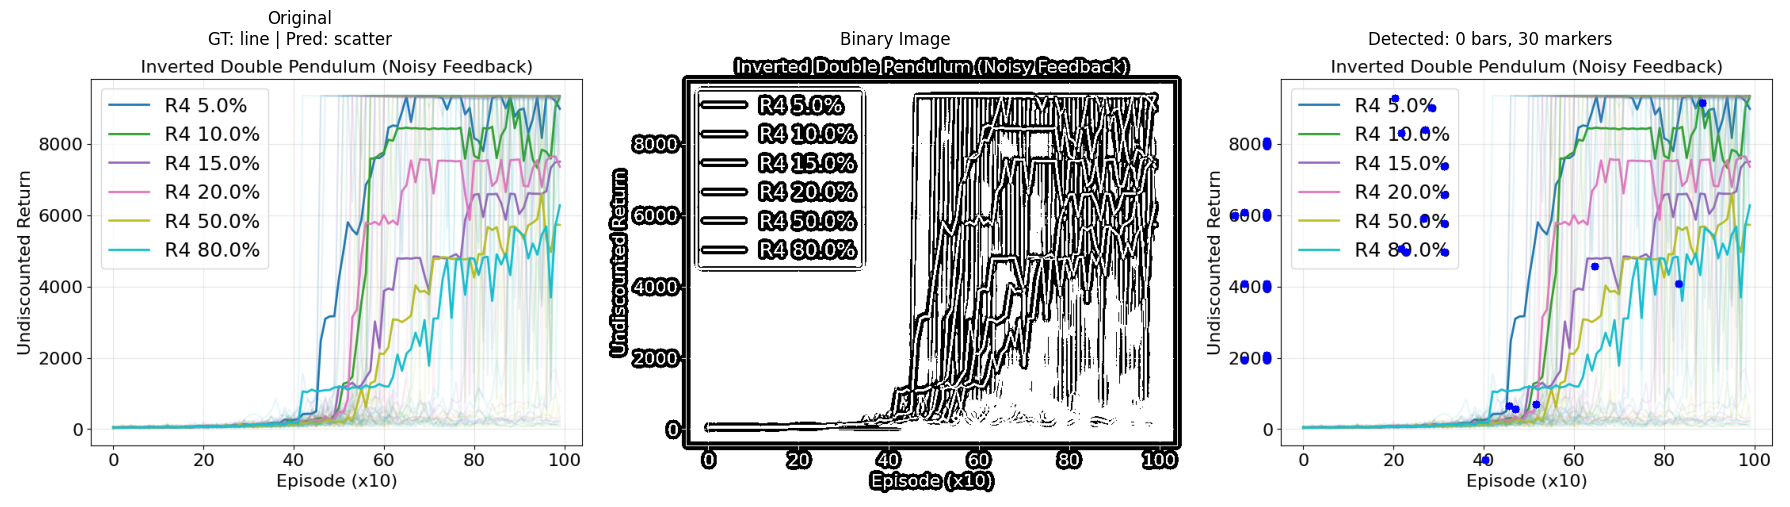


Detected 30 markers:
  1. Color: RGB(195, 200, 191), Center: (424,444)
  2. Color: RGB(232, 229, 239), Center: (498,270)
  3. Color: RGB(199, 199, 199), Center: (44,206)
  4. Color: RGB(198, 202, 211), Center: (398,450)
  5. Color: RGB(228, 228, 228), Center: (246,58)
  6. Color: RGB(191, 229, 230), Center: (604,292)
  7. Color: RGB(140, 188, 168), Center: (634,64)
  8. Color: RGB(193, 193, 193), Center: (292,70)
  9. Color: RGB(196, 196, 196), Center: (308,180)
  10. Color: RGB(193, 193, 193), Center: (308,252)


In [27]:
# Test element detection on line charts
print("Testing Element Detection on LINE Charts:")
print("=" * 60)

line_samples = get_samples_by_type(samples, 'line', n=3)
for sample in line_samples:
    print(f"\n--- {sample['image_id']} ---")
    test_element_detection(sample)

## 6. Batch Testing - Full Pipeline

In [28]:
def run_full_pipeline_test(samples, n_per_type=10):
    """Run full Stage 3 pipeline test on samples."""
    results = []
    
    chart_types_to_test = ['bar', 'line', 'pie', 'scatter']
    
    for chart_type in chart_types_to_test:
        type_samples = get_samples_by_type(samples, chart_type, n=n_per_type)
        print(f"\nProcessing {chart_type} charts ({len(type_samples)} samples)...")
        
        for sample in type_samples:
            img_path = Path(sample['image_path'])
            if not img_path.exists():
                continue
            
            try:
                img = cv2.imread(str(img_path))
                
                # Step 1: Preprocess
                preprocessed = preprocessor.process(img)
                
                # Step 2: Classify
                pred_type, type_conf = classifier.classify(img)
                
                # Step 3: Detect elements
                elements = element_detector.detect(img, pred_type)
                
                result = {
                    'image_id': sample['image_id'],
                    'ground_truth_type': sample['chart_type'],
                    'predicted_type': pred_type,
                    'type_confidence': type_conf,
                    'type_correct': pred_type == chart_type or 
                                   (chart_type == 'histogram' and pred_type == 'bar') or
                                   (chart_type == 'area' and pred_type == 'line'),
                    'elements_detected': len(elements),
                    'has_elements': len(elements) > 0,
                    'error': None
                }
                
            except Exception as e:
                result = {
                    'image_id': sample['image_id'],
                    'ground_truth_type': sample['chart_type'],
                    'predicted_type': None,
                    'type_confidence': 0,
                    'type_correct': False,
                    'elements_detected': 0,
                    'has_elements': False,
                    'error': str(e)
                }
            
            results.append(result)
    
    return results

# Run full pipeline test
print("Running Full Pipeline Test...")
print("=" * 60)

pipeline_results = run_full_pipeline_test(samples, n_per_type=25)

Running Full Pipeline Test...

Processing bar charts (25 samples)...

Processing line charts (25 samples)...

Processing pie charts (25 samples)...

Processing scatter charts (25 samples)...


In [29]:
# Analyze pipeline results
import pandas as pd

df = pd.DataFrame(pipeline_results)

print("\nPipeline Test Summary:")
print("=" * 60)
print(f"Total charts tested: {len(df)}")
print(f"Errors: {df['error'].notna().sum()}")
print()

# Classification accuracy
type_accuracy = df['type_correct'].mean() * 100
print(f"Classification Accuracy: {type_accuracy:.1f}%")

# Element detection rate
detection_rate = df['has_elements'].mean() * 100
print(f"Element Detection Rate: {detection_rate:.1f}%")

# Average elements detected
avg_elements = df['elements_detected'].mean()
print(f"Avg Elements Detected: {avg_elements:.1f}")


Pipeline Test Summary:
Total charts tested: 100
Errors: 100

Classification Accuracy: 0.0%
Element Detection Rate: 0.0%
Avg Elements Detected: 0.0


In [30]:
# Breakdown by chart type
print("\nResults by Chart Type:")
print("-" * 60)

for chart_type in df['ground_truth_type'].unique():
    type_df = df[df['ground_truth_type'] == chart_type]
    
    acc = type_df['type_correct'].mean() * 100
    det_rate = type_df['has_elements'].mean() * 100
    avg_elem = type_df['elements_detected'].mean()
    
    print(f"{chart_type:10} | Acc: {acc:5.1f}% | Det: {det_rate:5.1f}% | Avg Elem: {avg_elem:5.1f}")


Results by Chart Type:
------------------------------------------------------------
bar        | Acc:   0.0% | Det:   0.0% | Avg Elem:   0.0
line       | Acc:   0.0% | Det:   0.0% | Avg Elem:   0.0
pie        | Acc:   0.0% | Det:   0.0% | Avg Elem:   0.0
scatter    | Acc:   0.0% | Det:   0.0% | Avg Elem:   0.0


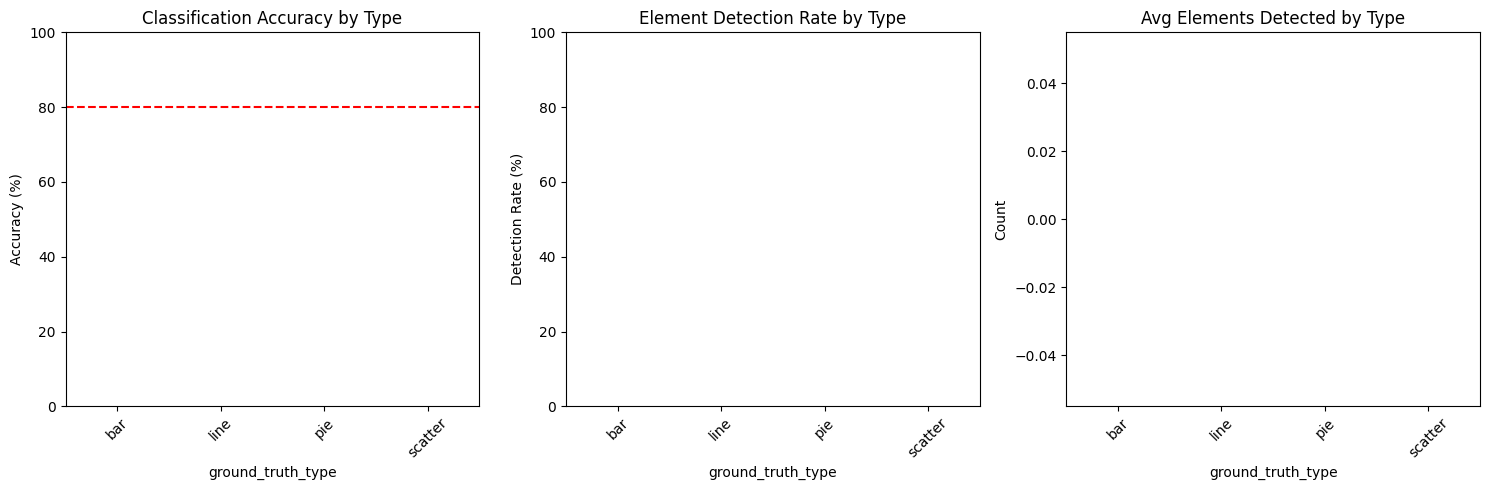

In [31]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Classification accuracy by type
type_acc = df.groupby('ground_truth_type')['type_correct'].mean() * 100
type_acc.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Classification Accuracy by Type')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=80, color='r', linestyle='--', label='80% threshold')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Element detection rate by type
det_rate = df.groupby('ground_truth_type')['has_elements'].mean() * 100
det_rate.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Element Detection Rate by Type')
axes[1].set_ylabel('Detection Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Average elements detected by type
avg_elem = df.groupby('ground_truth_type')['elements_detected'].mean()
avg_elem.plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Avg Elements Detected by Type')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Failure Analysis

In [ ]:
# Identify failure cases
failures = df[~df['type_correct'] | ~df['has_elements']]
print(f"Total failure cases: {len(failures)}")
print()

# Classification failures
class_failures = df[~df['type_correct']]
print(f"Classification failures: {len(class_failures)}")

# No elements detected
no_elements = df[~df['has_elements']]
print(f"No elements detected: {len(no_elements)}")

In [ ]:
# Show example failure cases
print("\nExample Failure Cases:")
print("=" * 60)

for _, row in failures.head(5).iterrows():
    sample = next((s for s in samples if s['image_id'] == row['image_id']), None)
    if sample:
        print(f"\n--- {row['image_id']} ---")
        print(f"Ground truth: {row['ground_truth_type']}")
        print(f"Predicted: {row['predicted_type']} (conf={row['type_confidence']:.2f})")
        print(f"Elements: {row['elements_detected']}")
        if row['error']:
            print(f"Error: {row['error']}")
        
        # Display the chart
        img_path = Path(sample['image_path'])
        if img_path.exists():
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(8, 6))
            plt.imshow(img_rgb)
            plt.title(f"Failure: {row['image_id']}")
            plt.axis('off')
            plt.show()

## 8. Save Results

In [ ]:
# Save results to JSON
from datetime import datetime

output_dir = project_root / "data" / "output"
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = output_dir / f"academic_dataset_test_{timestamp}.json"

summary = {
    'test_date': datetime.now().isoformat(),
    'total_tested': len(df),
    'classification_accuracy': type_accuracy,
    'detection_rate': detection_rate,
    'avg_elements': avg_elements,
    'by_type': df.groupby('ground_truth_type').agg({
        'type_correct': 'mean',
        'has_elements': 'mean',
        'elements_detected': 'mean'
    }).to_dict(),
    'results': pipeline_results
}

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Results saved to: {output_file}")

## 9. Summary

### Test Results Summary

| Metric | Value |
| --- | --- |
| Total Charts Tested | - |
| Classification Accuracy | - |
| Element Detection Rate | - |
| Avg Elements per Chart | - |

### Key Findings

1. **Classification Performance**: TBD after running
2. **Element Detection**: TBD after running
3. **Failure Patterns**: TBD after running

### Next Steps

1. Improve classifier for problematic chart types
2. Enhance K-Means segmentation for complex backgrounds
3. Add more training data for edge cases